In [1]:
import zipfile
from pathlib import Path
import pandas as pd

BASE_DIR  = Path("/home/natasha/multimodal_model") #/ "data" / "raw"
DATA_DIR = BASE_DIR / "data" / "raw"

zip_path = DATA_DIR / "ImmuneCODE-MIRA-Release002.1.zip"

# zip_path = Path("data/raw/ImmuneCODE-MIRA-Release002.1.zip")

with zipfile.ZipFile(zip_path, 'r') as z:
    print("Files inside zip:")
    for f in z.namelist():
        print(f)


Files inside zip:
ImmuneCODE-MIRA-Release002.1/minigene-detail.csv
ImmuneCODE-MIRA-Release002.1/minigene-hits.csv
ImmuneCODE-MIRA-Release002.1/orfs.csv
ImmuneCODE-MIRA-Release002.1/peptide-detail-ci.csv
ImmuneCODE-MIRA-Release002.1/peptide-detail-cii.csv
ImmuneCODE-MIRA-Release002.1/peptide-hits-ci.csv
ImmuneCODE-MIRA-Release002.1/peptide-hits-cii.csv
ImmuneCODE-MIRA-Release002.1/readme.txt
ImmuneCODE-MIRA-Release002.1/subject-metadata.csv


##### Load and Inspect Data

In [40]:
#zip_path = Path("data/raw/ImmuneCODE-MIRA-Release002.1.zip")
hits_path = [f for f in z.namelist() if "peptide-detail-ci.csv" in f][0]


with zipfile.ZipFile(zip_path, 'r') as z:
    for f in z.namelist():
        # if "peptide-hits-cii.csv" in f:
        #     hits_path = f
        #     break
        if "peptide-detail-ci.csv" in f:
            detail_path = f
            break

    print("Loading:", hits_path)
    df_hits = pd.read_csv(z.open(hits_path))

print("Shape:", df_hits.shape)
print("\nColumns:")
print(df_hits.columns.tolist())

df_hits.head()


Loading: ImmuneCODE-MIRA-Release002.1/peptide-detail-ci.csv
Shape: (154320, 7)

Columns:
['TCR BioIdentity', 'TCR Nucleotide Sequence', 'Experiment', 'ORF Coverage', 'Amino Acids', 'Start Index in Genome', 'End Index in Genome']


,TCR BioIdentity,TCR Nucleotide Sequence,Experiment,ORF Coverage,Amino Acids,Start Index in Genome,End Index in Genome
0,CASSAQGTGDRGYTF+TCRBV27-01+TCRBJ01-02,GAGTCGCCCAGCCCCAACCAGACCTCTCTGTACTTCTGTGCCAGCA...,eAV93,"ORF1ab,surface glycoprotein","ADAGFIKQY,AELEGIQY,LADAGFIKQY,TLADAGFIK",533,24073
1,CASSLVATGNTGELFF+TCRBV07-09+TCRBJ02-02,CGCACAGAGCAGGGGGACTCGGCCATGTATCTCTGTGCCAGCAGCT...,eOX56,"ORF1ab,surface glycoprotein","ADAGFIKQY,AELEGIQY,LADAGFIKQY,TLADAGFIK",533,24073
2,CASSKGTVSGLSG+TCRBV21-01+TCRBJ02-07,GAGATCCAGTCCACGGAGTCAGGGGACACAGCACTGTATTTCTGTG...,eAV93,"ORF1ab,surface glycoprotein","ADAGFIKQY,AELEGIQY,LADAGFIKQY,TLADAGFIK",533,24073
3,CALKVGADTQYF+TCRBV30-01+TCRBJ02-03,CTGAGTTCTAAGAAGCTCCTTCTCAGTGACTCTGGCTTCTATCTCT...,eQD124,"ORF1ab,surface glycoprotein","ADAGFIKQY,AELEGIQY,LADAGFIKQY,TLADAGFIK",533,24073
4,CASSLWASGRGGTGELFF+TCRBV27-01+TCRBJ02-02,AGCCCCAACCAGACCTCTCTGTACTTCTGTGCCAGCAGTTTATGGG...,eAV93,"ORF1ab,surface glycoprotein","ADAGFIKQY,AELEGIQY,LADAGFIKQY,TLADAGFIK",533,24073


In [ ]:
# check TCR chain is in-frame (length % 3 == 0) 
# does it contain stop codon?
# does it translate to a protein containing the CDR3 motif from TCR Bioidentity?

import re

def parse_bioidentity(bio):
    # "CASS...+TCRBV07-03+TCRBJ02-03"
    parts = str(bio).split("+")
    cdr3aa = parts[0]
    v = parts[1] if len(parts) > 1 else None
    j = parts[2] if len(parts) > 2 else None
    return cdr3aa, v, j

genetic_code = {
    'TTT':'F','TTC':'F','TTA':'L','TTG':'L','TCT':'S','TCC':'S','TCA':'S','TCG':'S',
    'TAT':'Y','TAC':'Y','TAA':'*','TAG':'*','TGT':'C','TGC':'C','TGA':'*','TGG':'W',
    'CTT':'L','CTC':'L','CTA':'L','CTG':'L','CCT':'P','CCC':'P','CCA':'P','CCG':'P',
    'CAT':'H','CAC':'H','CAA':'Q','CAG':'Q','CGT':'R','CGC':'R','CGA':'R','CGG':'R',
    'ATT':'I','ATC':'I','ATA':'I','ATG':'M','ACT':'T','ACC':'T','ACA':'T','ACG':'T',
    'AAT':'N','AAC':'N','AAA':'K','AAG':'K','AGT':'S','AGC':'S','AGA':'R','AGG':'R',
    'GTT':'V','GTC':'V','GTA':'V','GTG':'V','GCT':'A','GCC':'A','GCA':'A','GCG':'A',
    'GAT':'D','GAC':'D','GAA':'E','GAG':'E','GGT':'G','GGC':'G','GGA':'G','GGG':'G',
}

def translate(dna):
    dna = re.sub(r'[^ACGTacgt]', '', str(dna)).upper()
    prot = []
    for i in range(0, len(dna) - 2, 3):
        prot.append(genetic_code.get(dna[i:i+3], 'X'))
    return "".join(prot)

# quick sanity on a sample of rows
sample = df_hits.sample(20, random_state=0)

rows = []
for _, r in sample.iterrows():
    cdr3aa, v, j = parse_bioidentity(r["TCR BioIdentity"])
    dna = r["TCR Nucleotide Sequence"]
    prot = translate(dna)
    rows.append({
        "cdr3aa_from_bio": cdr3aa,
        "v": v,
        "j": j,
        "dna_len": len(str(dna)),
        "dna_mod3": len(re.sub(r'[^ACGTacgt]','',str(dna))) % 3,
        "prot_has_stop": "*" in prot,
        "cdr3aa_found_in_translation": cdr3aa in prot,
        "translation_preview": prot[:60]
    })

import pandas as pd
pd.DataFrame(rows)



AttributeError: 'list' object has no attribute 'to_csv'

In [42]:
# Add a new column with lengths of each peptide in 'Amino Acids'
# Example: "AAA,BC" -> [3, 2]

def _split_lengths(seq_str: str) -> list[int]:
    if pd.isna(seq_str):
        return []
    parts = [p.strip() for p in str(seq_str).split(',') if p.strip()]
    return [len(p) for p in parts]


df_hits["Amino Acid Lengths"] = df_hits["Amino Acids"].apply(_split_lengths)

df_hits[["Amino Acids", "Amino Acid Lengths"]].head()


,Amino Acids,Amino Acid Lengths
0,"ADAGFIKQY,AELEGIQY,LADAGFIKQY,TLADAGFIK","[9, 8, 10, 9]"
1,"ADAGFIKQY,AELEGIQY,LADAGFIKQY,TLADAGFIK","[9, 8, 10, 9]"
2,"ADAGFIKQY,AELEGIQY,LADAGFIKQY,TLADAGFIK","[9, 8, 10, 9]"
3,"ADAGFIKQY,AELEGIQY,LADAGFIKQY,TLADAGFIK","[9, 8, 10, 9]"
4,"ADAGFIKQY,AELEGIQY,LADAGFIKQY,TLADAGFIK","[9, 8, 10, 9]"


In [43]:
df_hits['Amino Acids'].str.len().describe()


count    154320.000000
mean         39.956836
std          36.876173
min           8.000000
25%          10.000000
50%          23.000000
75%          62.000000
max         136.000000
Name: Amino Acids, dtype: float64

In [44]:
df_hits[['Amino Acids','ORF Coverage']].head(10)


,Amino Acids,ORF Coverage
0,"ADAGFIKQY,AELEGIQY,LADAGFIKQY,TLADAGFIK","ORF1ab,surface glycoprotein"
1,"ADAGFIKQY,AELEGIQY,LADAGFIKQY,TLADAGFIK","ORF1ab,surface glycoprotein"
2,"ADAGFIKQY,AELEGIQY,LADAGFIKQY,TLADAGFIK","ORF1ab,surface glycoprotein"
3,"ADAGFIKQY,AELEGIQY,LADAGFIKQY,TLADAGFIK","ORF1ab,surface glycoprotein"
4,"ADAGFIKQY,AELEGIQY,LADAGFIKQY,TLADAGFIK","ORF1ab,surface glycoprotein"
5,"ADAGFIKQY,AELEGIQY,LADAGFIKQY,TLADAGFIK","ORF1ab,surface glycoprotein"
6,"ADAGFIKQY,AELEGIQY,LADAGFIKQY,TLADAGFIK","ORF1ab,surface glycoprotein"
7,"ADAGFIKQY,AELEGIQY,LADAGFIKQY,TLADAGFIK","ORF1ab,surface glycoprotein"
8,"ADAGFIKQY,AELEGIQY,LADAGFIKQY,TLADAGFIK","ORF1ab,surface glycoprotein"
9,"ADAGFIKQY,AELEGIQY,LADAGFIKQY,TLADAGFIK","ORF1ab,surface glycoprotein"


In [45]:
print(df_hits['ORF Coverage'].unique()[:10])


['ORF1ab,surface glycoprotein' 'ORF1ab' 'ORF1ab,ORF3a' 'envelope,ORF1ab'
 'surface glycoprotein' 'membrane glycoprotein,surface glycoprotein'
 'ORF3a' 'envelope' 'membrane glycoprotein' 'ORF6']


In [46]:
# how many experiments?
print("Unique experiments:", df_hits["Experiment"].nunique())

# how many unique peptide strings per experiment?
peptides_per_exp = (
    df_hits.groupby("Experiment")["Amino Acids"]
    .nunique()
    .sort_values(ascending=False)
)

print(peptides_per_exp.head(10))
print("\nSummary stats:")
print(peptides_per_exp.describe())


Unique experiments: 128
Experiment
eEE228    157
eAV93     156
eEE226    155
eXL30     155
eXL27     147
eAV88     143
eOX52     142
eEE224    140
eOX54     135
eXL31     129
Name: Amino Acids, dtype: int64

Summary stats:
count    128.000000
mean      61.226562
std       38.957521
min        5.000000
25%       30.500000
50%       54.000000
75%       87.000000
max      157.000000
Name: Amino Acids, dtype: float64


In [47]:
# count TCR duplicates per experiment
dup_check = (
    df_hits.groupby(["Experiment", "TCR BioIdentity"])
    .size()
    .reset_index(name="count")
)

print("Max duplicate count per (Experiment, TCR):", dup_check["count"].max())


Max duplicate count per (Experiment, TCR): 50


In [48]:
dup_examples = dup_check[dup_check["count"] > 1]
dup_examples.head()


,Experiment,TCR BioIdentity,count
316,eAM23,CASSLTGASTDTQYF+TCRBV07-03+TCRBJ02-03,2
527,eAM23,unproductive+TCRBV06-05+TCRBJ02-07,3
529,eAM23,unproductive+TCRBV07-08+TCRBJ02-07,2
530,eAM23,unproductive+TCRBV09-01+TCRBJ01-05,2
531,eAM23,unproductive+TCRBV09-01+TCRBJ02-02,2


In [49]:
exp = dup_examples.iloc[0]["Experiment"]
tcr = dup_examples.iloc[0]["TCR BioIdentity"]

df_hits[(df_hits["Experiment"] == exp) & 
        (df_hits["TCR BioIdentity"] == tcr)]


,TCR BioIdentity,TCR Nucleotide Sequence,Experiment,ORF Coverage,Amino Acids,Start Index in Genome,End Index in Genome,Amino Acid Lengths
31964,CASSLTGASTDTQYF+TCRBV07-03+TCRBJ02-03,CAGCGCACAGAGCGGGGGGACTCAGCCGTGTATCTCTGTGCCAGCA...,eAM23,ORF1ab,MPASWVMRI,11228,11254,[9]
153586,CASSLTGASTDTQYF+TCRBV07-03+TCRBJ02-03,CAGCGCACAGAGCGGGGGGACTCAGCCGTGTATCTCTGTGCCAGCA...,eAM23,ORF10,"AFPFTIYSL,GYINVFAFPF,INVFAFPFTI,MGYINVFAF,NVFA...",29558,29605,"[9, 10, 10, 9, 9, 10, 9]"


In [50]:
# check 

<Axes: >

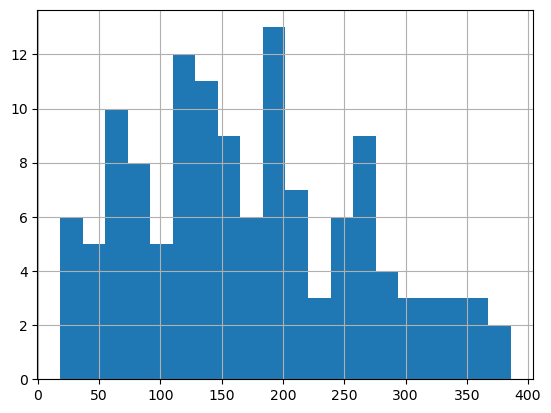

In [51]:
# expand minimal epitopes
df_expanded = (
    df_hits
    .assign(epitope=df_hits["Amino Acids"].str.split(","))
    .explode("epitope")
)

epitopes_per_exp = (
    df_expanded.groupby("Experiment")["epitope"]
    .nunique()
)

epitopes_per_exp.hist(bins=20)


In [52]:
# check there are no peptides with 0 hits?



##### Build 'Negative' Dataset

In [53]:
import pandas as pd
import numpy as np
import zipfile
from pathlib import Path

BASE_DIR  = Path("/home/natasha/multimodal_model") #/ "data" / "raw"
DATA_DIR = BASE_DIR / "data" / "raw"

zip_path = DATA_DIR / "ImmuneCODE-MIRA-Release002.1.zip"

with zipfile.ZipFile(zip_path, 'r') as z:
    df = pd.read_csv(z.open(detail_path))

# minimal structural cleanup
df = df.dropna(subset=["Experiment", "TCR BioIdentity", "Amino Acids"]).copy()
df["Experiment"] = df["Experiment"].astype(str).str.strip()
df["TCR BioIdentity"] = df["TCR BioIdentity"].astype(str).str.strip()
df["Amino Acids"] = df["Amino Acids"].astype(str).str.strip()

# remove unproductive entries
df = df[~df["TCR BioIdentity"].str.contains("unproductive", case=False, na=False)].copy()


In [54]:
df.head()

,TCR BioIdentity,TCR Nucleotide Sequence,Experiment,ORF Coverage,Amino Acids,Start Index in Genome,End Index in Genome
0,CASSAQGTGDRGYTF+TCRBV27-01+TCRBJ01-02,GAGTCGCCCAGCCCCAACCAGACCTCTCTGTACTTCTGTGCCAGCA...,eAV93,"ORF1ab,surface glycoprotein","ADAGFIKQY,AELEGIQY,LADAGFIKQY,TLADAGFIK",533,24073
1,CASSLVATGNTGELFF+TCRBV07-09+TCRBJ02-02,CGCACAGAGCAGGGGGACTCGGCCATGTATCTCTGTGCCAGCAGCT...,eOX56,"ORF1ab,surface glycoprotein","ADAGFIKQY,AELEGIQY,LADAGFIKQY,TLADAGFIK",533,24073
2,CASSKGTVSGLSG+TCRBV21-01+TCRBJ02-07,GAGATCCAGTCCACGGAGTCAGGGGACACAGCACTGTATTTCTGTG...,eAV93,"ORF1ab,surface glycoprotein","ADAGFIKQY,AELEGIQY,LADAGFIKQY,TLADAGFIK",533,24073
3,CALKVGADTQYF+TCRBV30-01+TCRBJ02-03,CTGAGTTCTAAGAAGCTCCTTCTCAGTGACTCTGGCTTCTATCTCT...,eQD124,"ORF1ab,surface glycoprotein","ADAGFIKQY,AELEGIQY,LADAGFIKQY,TLADAGFIK",533,24073
4,CASSLWASGRGGTGELFF+TCRBV27-01+TCRBJ02-02,AGCCCCAACCAGACCTCTCTGTACTTCTGTGCCAGCAGTTTATGGG...,eAV93,"ORF1ab,surface glycoprotein","ADAGFIKQY,AELEGIQY,LADAGFIKQY,TLADAGFIK",533,24073


In [55]:
# expand minimal epitopes per row

def split_epitopes(s):
    return [p.strip() for p in str(s).split(",") if p.strip()]

df_exp = df.assign(epitope=df["Amino Acids"].map(split_epitopes)).explode("epitope")
df_exp["epitope_len"] = df_exp["epitope"].str.len()
df_exp = df_exp[df_exp["epitope_len"].between(8, 11)].copy()


In [57]:
# define positive set per (Experiment, TCR)

pos_sets = (
    df_exp.groupby(["Experiment", "TCR BioIdentity"])["epitope"]
    .apply(lambda x: set(x.unique()))
    .reset_index(name="pos_epitopes")
)


In [58]:
# Define epitope universe per experiment

exp_universe = (
    df_exp.groupby("Experiment")["epitope"]
    .apply(lambda x: np.array(sorted(set(x.unique()))))
    .to_dict()
)


# remove experiments with less than 20 unique peptides, too small to yield meaningful negatives
min_panel_size = 20
valid_exps = {e for e, peps in exp_universe.items() if len(peps) >= min_panel_size}
pos_sets = pos_sets[pos_sets["Experiment"].isin(valid_exps)].copy()


In [59]:
# construct negative set with controlled sampling - do not take full complement

rng = np.random.default_rng(0)

def sample_negatives(exp, pos_set, k):
    universe = exp_universe[exp]
    # mask out positives
    neg_candidates = universe[~np.isin(universe, list(pos_set))]
    return neg_candidates

k_neg_per_pos = 5  # adjust (5–20 typical)

rows = []
for _, r in pos_sets.iterrows():
    exp = r["Experiment"]
    tcr = r["TCR BioIdentity"]
    pos = sorted(r["pos_epitopes"])
    neg_candidates = sample_negatives(exp, set(pos), k=0)

    if len(neg_candidates) == 0:
        continue

    # sample negatives proportional to #positives
    n_to_sample = min(len(neg_candidates), k_neg_per_pos * len(pos))
    neg_sample = rng.choice(neg_candidates, size=n_to_sample, replace=False)

    # positives
    for pep in pos:
        rows.append((exp, tcr, pep, 1))

    # negatives
    for pep in neg_sample:
        rows.append((exp, tcr, pep, 0))

dataset = pd.DataFrame(rows, columns=["Experiment", "TCR_BioIdentity", "epitope", "label"])


In [60]:
dataset

,Experiment,TCR_BioIdentity,epitope,label
0,eAM13,CAATGGAVEKLFF+TCRBV10-03+TCRBJ01-04,LLMPILTLT,1
1,eAM13,CAATGGAVEKLFF+TCRBV10-03+TCRBJ01-04,QLMCQPILLL,0
2,eAM13,CAATGGAVEKLFF+TCRBV10-03+TCRBJ01-04,LYIIKLIFL,0
3,eAM13,CAATGGAVEKLFF+TCRBV10-03+TCRBJ01-04,GMEVTPSGTWL,0
4,eAM13,CAATGGAVEKLFF+TCRBV10-03+TCRBJ01-04,IAMACLVGLM,0
...,...,...,...,...
3392156,eXL43,CSVELEQLVQETQYF+TCRBV29-01+TCRBJ02-05,FLQSINFVRI,0
3392157,eXL43,CSVELEQLVQETQYF+TCRBV29-01+TCRBJ02-05,YDANYFLCW,0
3392158,eXL43,CSVELEQLVQETQYF+TCRBV29-01+TCRBJ02-05,LQSINFVRI,0
3392159,eXL43,CSVELEQLVQETQYF+TCRBV29-01+TCRBJ02-05,FYLCFLAFLL,0


In [61]:
# remove any accidental label contradictions 

# if same (exp,tcr,epitope) appears with both labels -> drop or resolve
conflicts = (dataset.groupby(["Experiment","TCR_BioIdentity","epitope"])["label"]
             .nunique())
bad = conflicts[conflicts > 1]
print("Conflicting triplets:", len(bad))

if len(bad) > 0:
    # safest: keep as positive
    dataset = (dataset.groupby(["Experiment","TCR_BioIdentity","epitope"])["label"]
               .max().reset_index())


Conflicting triplets: 0


In [62]:
dataset

,Experiment,TCR_BioIdentity,epitope,label
0,eAM13,CAATGGAVEKLFF+TCRBV10-03+TCRBJ01-04,LLMPILTLT,1
1,eAM13,CAATGGAVEKLFF+TCRBV10-03+TCRBJ01-04,QLMCQPILLL,0
2,eAM13,CAATGGAVEKLFF+TCRBV10-03+TCRBJ01-04,LYIIKLIFL,0
3,eAM13,CAATGGAVEKLFF+TCRBV10-03+TCRBJ01-04,GMEVTPSGTWL,0
4,eAM13,CAATGGAVEKLFF+TCRBV10-03+TCRBJ01-04,IAMACLVGLM,0
...,...,...,...,...
3392156,eXL43,CSVELEQLVQETQYF+TCRBV29-01+TCRBJ02-05,FLQSINFVRI,0
3392157,eXL43,CSVELEQLVQETQYF+TCRBV29-01+TCRBJ02-05,YDANYFLCW,0
3392158,eXL43,CSVELEQLVQETQYF+TCRBV29-01+TCRBJ02-05,LQSINFVRI,0
3392159,eXL43,CSVELEQLVQETQYF+TCRBV29-01+TCRBJ02-05,FYLCFLAFLL,0


In [63]:
# split by experiment? or by epitope

exps = dataset["Experiment"].unique()
rng = np.random.default_rng(0)
rng.shuffle(exps)

n = len(exps)
train_exps = set(exps[: int(0.8*n)])
val_exps   = set(exps[int(0.8*n): int(0.9*n)])
test_exps  = set(exps[int(0.9*n):])

dataset["split"] = np.where(dataset["Experiment"].isin(train_exps), "train",
                     np.where(dataset["Experiment"].isin(val_exps), "val", "test"))


##### IMMREP Test Set

In [66]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path("/home/natasha/multimodal_model")
DATA_DIR = BASE_DIR / "data" / "raw"

tsv_file = DATA_DIR / "immrep2025_for_release.tsv"
csv_file = DATA_DIR / "immrep2025_for_release.csv"

# Load TSV
df = pd.read_csv(tsv_file, sep="\t")

# Save as CSV
df.to_csv(csv_file, index=False)

print("Shape:", df.shape)
df.head()


Shape: (10000, 19)


,tcra_bioIdentity,tcra_cdr1,tcra_cdr2,tcra_cdr3,tcra_v,tcra_j,tcra_trimmed,tcrb_bioIdentity,tcrb_cdr1,tcrb_cdr2,tcrb_cdr3,tcrb_v,tcrb_j,tcrb_trimmed,peptide,hla,hla_sequence,hla_trimmed,label
0,CAVGAGNNAGNMLTF+TCRAV08-03+TCRAJ39-01,YGATPY,YFSGDTLV,CAVGAGNNAGNMLTF,TCRAV08-03,TCRAJ39-01,AQSVTQPDIHITVSEGASLELRCNYSYGATPYLFWYVQSPGQGLQL...,CASSLALLEGLGDTEAFF+TCRBV07-06+TCRBJ01-01,SGHVS,FNYEAQ,CASSLALLEGLGDTEAFF,TCRBV07-06,TCRBJ01-01,GAGVSQSPRYKVTKRGQDVALRCDPISGHVSLYWYRQALGQGPEFL...,MENWSALEL,B*40:01,MRVTAPRTVLLLLSAALALTETWAGSHSMRYFHTAMSRPGRGEPRF...,GSHSMRYFHTAMSRPGRGEPRFITVGYVDDTLFVRFDSDATSPRKE...,1
1,CAVESENNAGNMLTF+TCRAV22-01+TCRAJ39-01,DSVNN,IPSGT,CAVESENNAGNMLTF,TCRAV22-01,TCRAJ39-01,GIQVEQSPPDLILQEGANSTLRCNFSDSVNNLQWFHQNPWGQLINL...,CASSTKPGWGLTGELFF+TCRBV12-X+TCRBJ02-02,SGHNS,FNNNVP,CASSTKPGWGLTGELFF,TCRBV12-X,TCRBJ02-02,DAGVIQSPRHEVTEMGQEVTLRCKPISGHNSLFWYRQTMMRGLELL...,TVYPYGTSL,A*02:01,MAVMAPRTLVLLLSGALALTQTWAGSHSMRYFFTSVSRPGRGEPRF...,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,1
2,CGTRDYKLSF+TCRAV30-01+TCRAJ20-01,KALYS,LLKGGEQ,CGTRDYKLSF,TCRAV30-01,TCRAJ20-01,SQQPVQSPQAVILREGEDAVINCSSSKALYSVHWYRQKHGEAPVFL...,CASSSTGGTNEKLFF+TCRBV12-X+TCRBJ01-04,SGHNS,FNNNVP,CASSSTGGTNEKLFF,TCRBV12-X,TCRBJ01-04,DAGVIQSPRHEVTEMGQEVTLRCKPISGHNSLFWYRQTMMRGLELL...,MEMPDYLLL,B*40:01,MRVTAPRTVLLLLSAALALTETWAGSHSMRYFHTAMSRPGRGEPRF...,GSHSMRYFHTAMSRPGRGEPRFITVGYVDDTLFVRFDSDATSPRKE...,1
3,CAVWSPGGSYIPTF+TCRAV12-02+TCRAJ06-01,DRGSQS,IYSNGD,CAVWSPGGSYIPTF,TCRAV12-02,TCRAJ06-01,QKEVEQNSGPLSVPEGAIASLNCTYSDRGSQSFFWYRQYSGKSPEL...,CASTTISGGAGANVLTF+TCRBV12-X+TCRBJ02-06,SGHNS,FNNNVP,CASTTISGGAGANVLTF,TCRBV12-X,TCRBJ02-06,DAGVIQSPRHEVTEMGQEVTLRCKPISGHNSLFWYRQTMMRGLELL...,TVYPYGTSL,A*02:01,MAVMAPRTLVLLLSGALALTQTWAGSHSMRYFFTSVSRPGRGEPRF...,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,1
4,CAKAGGGNKLTF+TCRAV13-01+TCRAJ10-01,DSASNY,IRSNVGE,CAKAGGGNKLTF,TCRAV13-01,TCRAJ10-01,GENVEQHPSTLSVQEGDSAVIKCTYSDSASNYFPWYKQELGKGPQL...,CASNRDTTDTQYF+TCRBV09-01+TCRBJ02-03,SGDLS,YYNGEE,CASNRDTTDTQYF,TCRBV09-01,TCRBJ02-03,DSGVTQTPKHLITATGQRVTLRCSPRSGDLSVYWYQQSLDQGLQFL...,ILHTHVPEV,A*02:01,MAVMAPRTLVLLLSGALALTQTWAGSHSMRYFFTSVSRPGRGEPRF...,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,1
